In [1]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels pulp openpyxl jupyter

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_events-0.12.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached prometheus_client-0.26.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached send2trash-2.1.0-py3-


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_1samp, f_oneway

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.formula.api import ols

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(
    "OnlineRetail.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 5268


In [8]:
display(df.dtypes)

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [9]:
df = df.dropna(subset=["CustomerID"])

In [10]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [11]:
df = df.drop_duplicates()

In [12]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [13]:
df["Total_Sales"] = (
    df["Quantity"] * df["UnitPrice"]
)

In [14]:
columns = [
    "Quantity",
    "UnitPrice",
    "Total_Sales"
]

display(df[columns].describe())

,Quantity,UnitPrice,Total_Sales
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [15]:
print("Total Sales:", df["Total_Sales"].sum())
print("Average Sales:", df["Total_Sales"].mean())
print("Median Sales:", df["Total_Sales"].median())
print("Maximum Sales:", df["Total_Sales"].max())
print("Minimum Sales:", df["Total_Sales"].min())

Total Sales: 8887208.894000001
Average Sales: 22.631499735161402
Median Sales: 12.45
Maximum Sales: 168469.6
Minimum Sales: 0.001


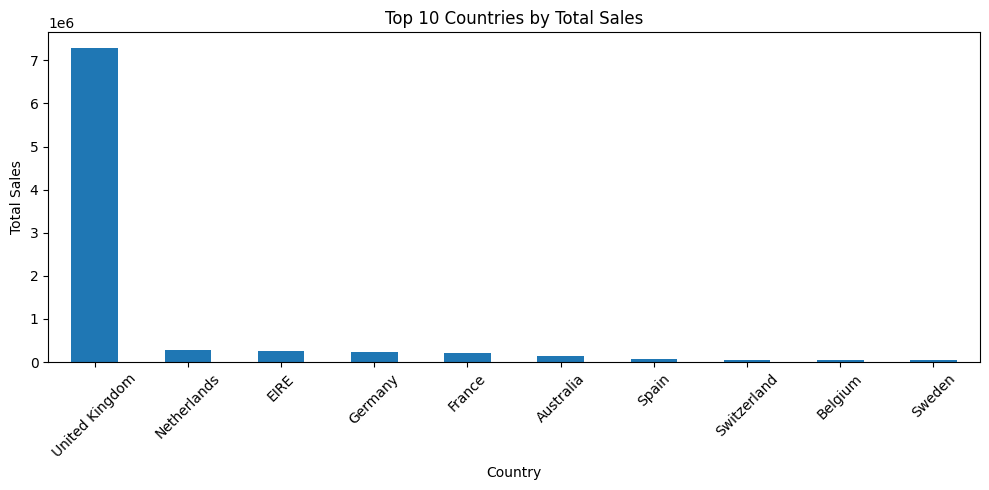

In [16]:
country_sales = (
    df.groupby("Country")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

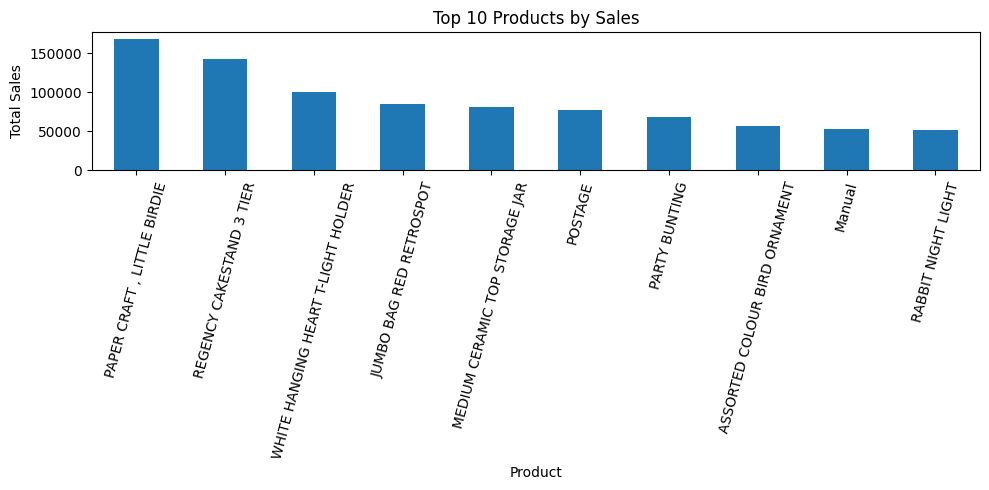

In [17]:
product_sales = (
    df.groupby("Description")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

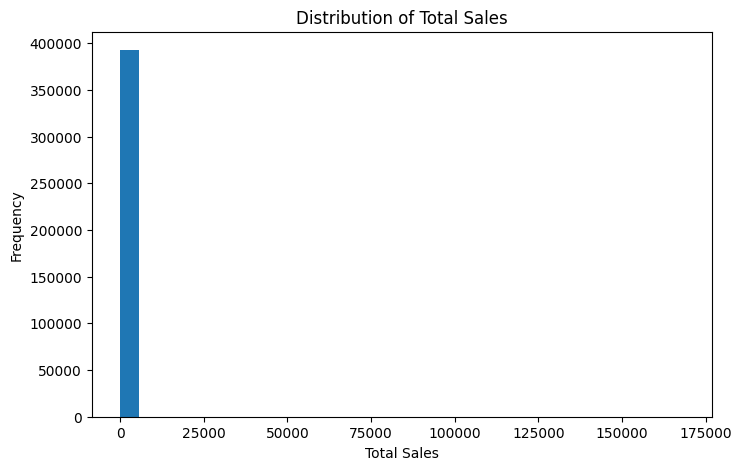

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Total_Sales"],
    bins=30
)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

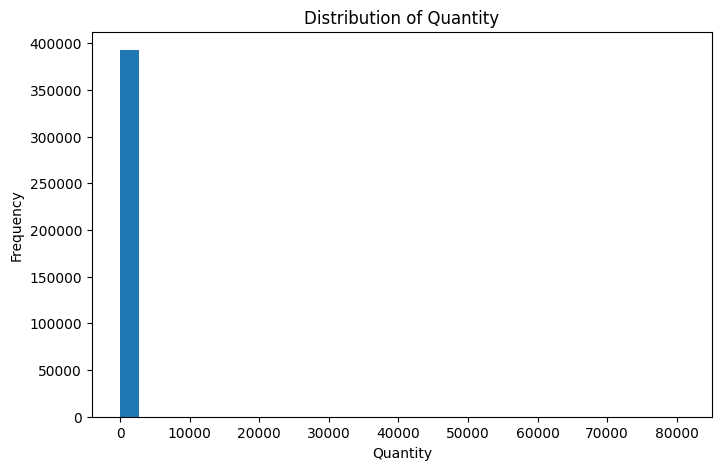

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Quantity"],
    bins=30
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

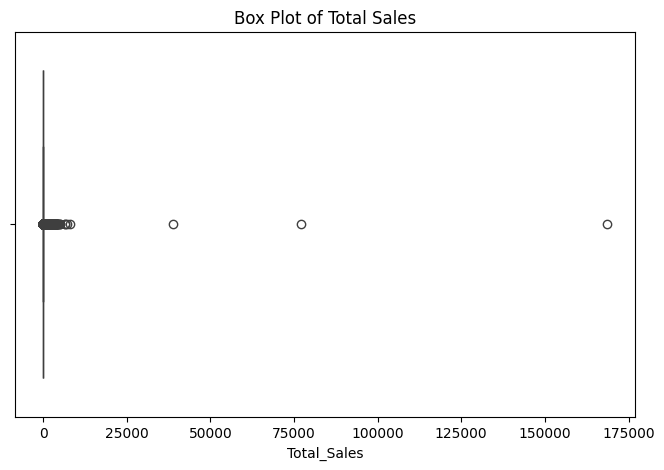

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Total_Sales"]
)

plt.title("Box Plot of Total Sales")

plt.show()

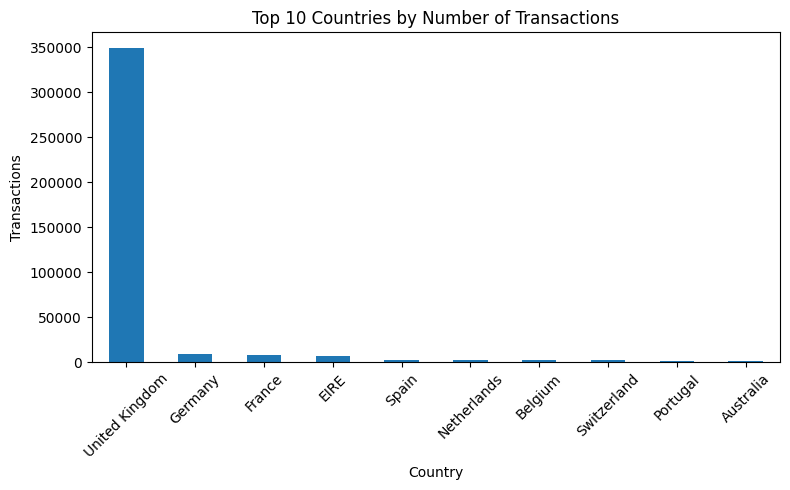

In [21]:
country_count = df["Country"].value_counts().head(10)

plt.figure(figsize=(8,5))

country_count.plot(kind="bar")

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

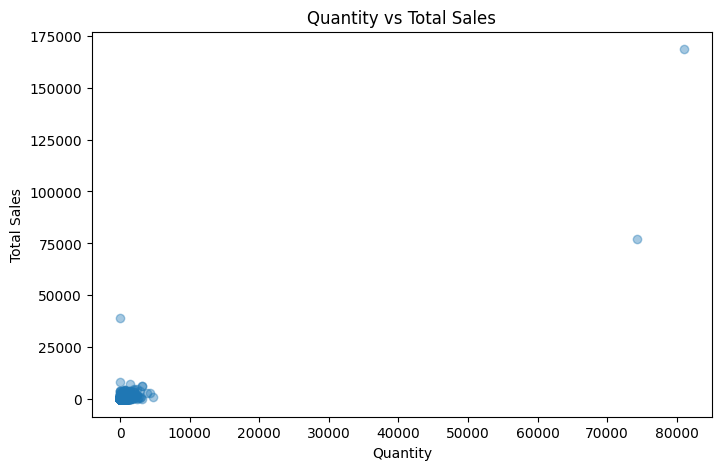

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Quantity"],
    df["Total_Sales"],
    alpha=0.4
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()

In [23]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "Total_Sales"
]

correlation = df[numeric_columns].corr()

display(correlation)

,Quantity,UnitPrice,Total_Sales
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
Total_Sales,0.914451,0.081619,1.000000


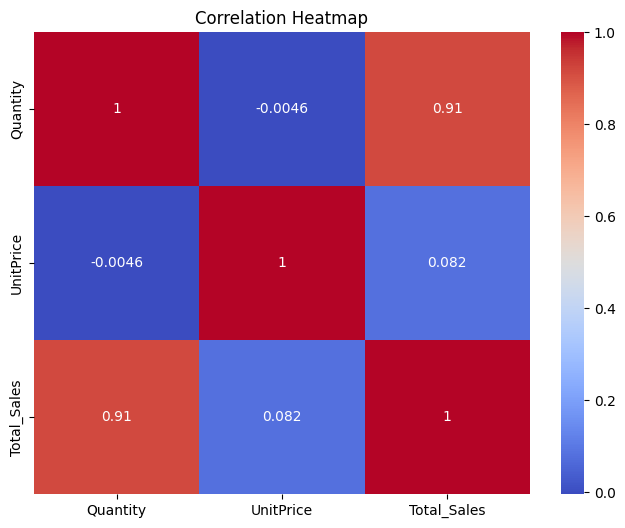

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
regression_df = df[
    ["Quantity", "Total_Sales"]
].dropna()

X = regression_df[["Quantity"]]
y = regression_df["Total_Sales"]

model = LinearRegression()

model.fit(X, y)

prediction = model.predict(X)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

print(
    "R-squared:",
    r2_score(y, prediction)
)

print(
    "MSE:",
    mean_squared_error(y, prediction)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y, prediction))
)

Coefficient: 1.5761563835138797
Intercept: 1.9527977494416113
R-squared: 0.8362202347320562
MSE: 15851.012007467581
RMSE: 125.90080225108807


In [26]:
total_records = len(df)

uk_records = (
    df["Country"] == "United Kingdom"
).sum()

probability_uk = (
    uk_records / total_records
)

print(
    "Probability of UK transaction:",
    probability_uk
)

Probability of UK transaction: 0.8892541737544947


In [27]:
sales = df["Total_Sales"].dropna()

sample_sizes = [30, 50, 100]

for size in sample_sizes:

    sample_means = []

    for _ in range(100):

        sample = sales.sample(
            size,
            replace=True
        )

        sample_means.append(
            sample.mean()
        )

    print("Sample Size:", size)
    print(
        "Mean of Sample Means:",
        np.mean(sample_means)
    )

    print(
        "Standard Error:",
        np.std(
            sample_means,
            ddof=1
        )
    )

Sample Size: 30
Mean of Sample Means: 22.799536666666665
Standard Error: 28.629916518418568
Sample Size: 50
Mean of Sample Means: 19.540036
Standard Error: 5.615131259995063
Sample Size: 100
Mean of Sample Means: 29.626795
Standard Error: 76.91705051181071


In [28]:
sales = df["Total_Sales"].dropna()

mean = sales.mean()

n = len(sales)

standard_error = stats.sem(sales)

lower, upper = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean,
    scale=standard_error
)

print("Mean Sales:", mean)

print(
    "95% Confidence Interval:",
    (lower, upper)
)

Mean Sales: 22.631499735161402
95% Confidence Interval: (np.float64(21.658478471778487), np.float64(23.604520998544317))


In [29]:
sales = df["Total_Sales"].dropna().to_numpy()

bootstrap_means = []

for _ in range(1000):

    sample = np.random.choice(
        sales,
        size=len(sales),
        replace=True
    )

    bootstrap_means.append(
        sample.mean()
    )

lower, upper = np.percentile(
    bootstrap_means,
    [2.5, 97.5]
)

print(
    "Bootstrap Mean:",
    np.mean(bootstrap_means)
)

print(
    "Bootstrap 95% CI:",
    (lower, upper)
)

Bootstrap Mean: 22.647754859678834
Bootstrap 95% CI: (np.float64(21.855508334076074), np.float64(23.695747015409022))


In [30]:
test_value = 100

In [31]:
sales = df["Total_Sales"].dropna()

result = ttest_1samp(
    sales,
    popmean=test_value
)

print("H0: Mean Total Sales =", test_value)
print("H1: Mean Total Sales is different")

print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

H0: Mean Total Sales = 100
H1: Mean Total Sales is different
t-statistic: -155.84442720109215
p-value: 0.0
Decision: Reject H0


In [39]:
ab = pd.read_csv("OnlineRetail_AB_Testing_Dataset.csv")
 
display(ab.head())
 
display(ab.groupby("Variant")["Converted"].agg(["sum", "count", "mean"]))

,Visitor_ID,Variant,Message,Converted
0,V0001,B,Get 20% Off,0
1,V0002,A,Shop Now,0
2,V0003,B,Get 20% Off,0
3,V0004,A,Shop Now,0
4,V0005,B,Get 20% Off,0


,sum,count,mean
Variant,,,
A,110,1000,0.110
B,145,1000,0.145


In [41]:
from statsmodels.stats.proportion import proportions_ztest
 
summary = ab.groupby("Variant")["Converted"].agg(["sum", "count"])
 
z_stat, p_value = proportions_ztest(summary["sum"].to_numpy(), summary["count"].to_numpy())
 
print("Z-statistic:", z_stat)
 
print("P-value:", p_value)
 
print("Decision:", "Significant difference" if p_value < 0.05 else "No significant difference detected")

Z-statistic: -2.346471244078323
P-value: 0.018952128575399498
Decision: Significant difference


In [42]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

dated_df = df.dropna(
    subset=["InvoiceDate"]
).copy()

monthly_sales = (
    dated_df
    .groupby(
        dated_df["InvoiceDate"].dt.to_period("M")
    )["Total_Sales"]
    .sum()
)

monthly_sales.index = (
    monthly_sales.index.to_timestamp()
)

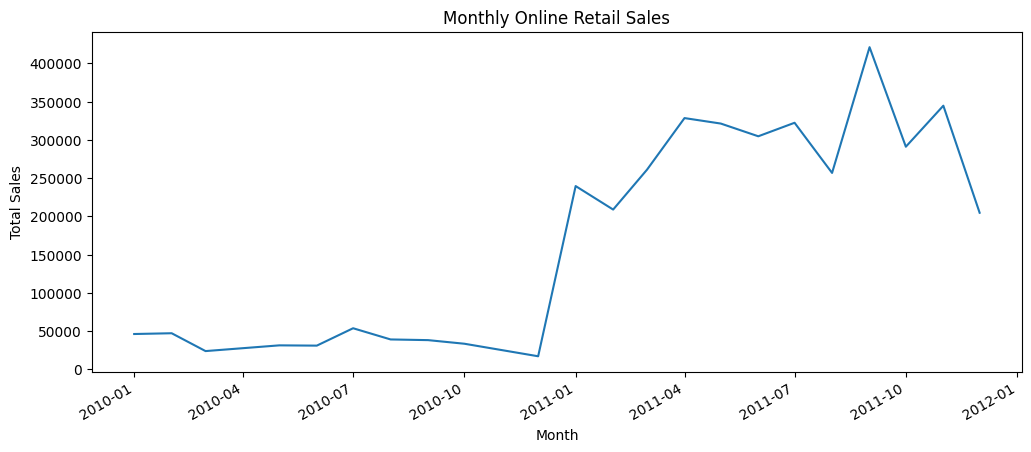

In [43]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Online Retail Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

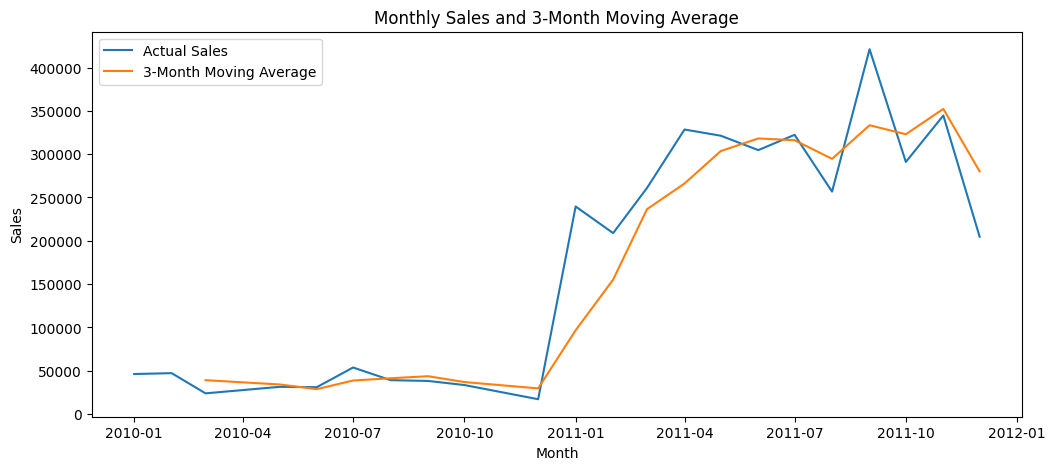

In [44]:
moving_average = (
    monthly_sales
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Actual Sales"
)

plt.plot(
    moving_average.index,
    moving_average.values,
    label="3-Month Moving Average"
)

plt.title(
    "Monthly Sales and 3-Month Moving Average"
)

plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [46]:
simulation = pd.read_csv("OnlineRetail_Simulation_Dataset.csv")
 
print("Available columns:", simulation.columns.tolist())
 
display(simulation.head())
 

Available columns: ['Simulation_ID', 'Scenario', 'Demand', 'Unit_Price', 'Sales']


,Simulation_ID,Scenario,Demand,Unit_Price,Sales
0,1,Low,14131,1.80,25444.79
1,2,Low,11406,1.96,22368.56
2,3,Low,15035,1.76,26515.54
3,4,Low,15420,1.85,28474.43
4,5,Low,9559,1.44,13788.61


In [47]:
if "Scenario" in simulation.columns:
 
    numeric_cols = simulation.select_dtypes(include="number").columns.tolist()
 
    numeric_cols = [c for c in numeric_cols if c != "Simulation_ID"]
 
    display(simulation.groupby("Scenario")[numeric_cols].mean().loc[["Low", "Normal", "High"]])
 
else:
 
    print("No Scenario column found. Check the available column names above.")

,Demand,Unit_Price,Sales
Scenario,,,
Low,13451.89,1.75325,23562.2093
Normal,16719.38,1.74470,29201.9300
High,20181.58,1.75180,35352.0699


In [48]:
top_countries = (
    df["Country"]
    .value_counts()
    .head(5)
    .index
)

anova_df = df[
    df["Country"].isin(top_countries)
].copy()

In [49]:
groups = []

for country in top_countries:

    values = anova_df[
        anova_df["Country"] == country
    ]["Total_Sales"].dropna()

    groups.append(values)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference detected")
else:
    print("No significant difference detected")

F-statistic: 5.171925593881521
P-value: 0.00036524539626795534
Significant difference detected


In [51]:
factorial = pd.read_csv("OnlineRetail_Factorial_Experiment_Dataset.csv")
 
print("Available columns:", factorial.columns.tolist())
 
display(factorial.head())

Available columns: ['Experiment_ID', 'Sales_Channel', 'Promotion_Level', 'Sales']


,Experiment_ID,Sales_Channel,Promotion_Level,Sales
0,1,Online,Low,29914.15
1,2,Online,Low,25880.05
2,3,Online,Low,31251.35
3,4,Online,Low,31821.69
4,5,Online,Low,23146.89


Promotion_Level,Low,Medium,High
Sales_Channel,,,
Online,28901.2025,34828.386,42357.9795
Store,24721.0845,27937.302,33666.8105


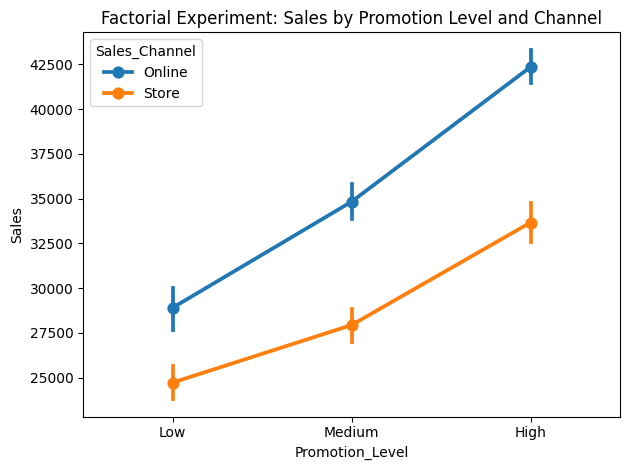

In [52]:
if {"Sales_Channel", "Promotion_Level", "Sales"}.issubset(factorial.columns):
 
    order = ["Low", "Medium", "High"]
 
    display(factorial.groupby(["Sales_Channel", "Promotion_Level"])["Sales"].mean().unstack()[order])
 
    sns.pointplot(data=factorial, x="Promotion_Level", y="Sales", hue="Sales_Channel", order=order)
 
    plt.title("Factorial Experiment: Sales by Promotion Level and Channel")
 
    plt.tight_layout()
 
    plt.show()
 
else:
 
    print("Expected columns not found; check the column list in the previous cell.")

In [53]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
 
factorial_model = ols("Sales ~ C(Sales_Channel) * C(Promotion_Level)", data=factorial).fit()
 
display(sm.stats.anova_lm(factorial_model, typ=2))

,sum_sq,df,F,PR(>F)
C(Sales_Channel),1.301838e+09,1.0,234.657545,1.921085e-29
C(Promotion_Level),2.537592e+09,2.0,228.701780,1.252647e-40
C(Sales_Channel):C(Promotion_Level),1.031307e+08,2.0,9.294710,1.822094e-04
Residual,6.324514e+08,114.0,NaN,NaN


In [54]:
decision = pd.read_csv("OnlineRetail_Decision_Making_Dataset.csv")
 
print("Available columns:", decision.columns.tolist())
 
display(decision)
 
# %% [markdown]
# ## 22.2 Expected Value by Alternative
 
# %%
if {"Alternative", "Probability", "Payoff_INR"}.issubset(decision.columns):
 
    decision["Expected_Value"] = decision["Probability"] * decision["Payoff_INR"]
 
    values = decision.groupby("Alternative")["Expected_Value"].sum().sort_values(ascending=False)
 
    display(values)
 
    print("Best alternative:", values.idxmax())
 
    print("Expected value:", values.max())
 
else:
 
    print("Expected columns not found; check the column list above.")
 

Available columns: ['Alternative', 'Outcome', 'Probability', 'Payoff_INR']


,Alternative,Outcome,Probability,Payoff_INR
0,Increase Advertising,Strong response,0.30,900000
1,Increase Advertising,Moderate response,0.50,450000
2,Increase Advertising,Weak response,0.20,-150000
3,Offer Discount,Strong response,0.25,800000
4,Offer Discount,Moderate response,0.45,400000
5,Offer Discount,Weak response,0.30,-200000
6,Launch New Product,Strong response,0.20,1500000
7,Launch New Product,Moderate response,0.40,500000
8,Launch New Product,Weak response,0.40,-500000
9,Expand Market,Strong response,0.25,1200000


Alternative
Increase Advertising    465000.0
Expand Market           450000.0
Offer Discount          320000.0
Launch New Product      300000.0
Name: Expected_Value, dtype: float64

Best alternative: Increase Advertising
Expected value: 465000.0


In [56]:
optimization = pd.read_csv("OnlineRetail_Optimization_Input_Dataset.csv")
 
display(optimization)
 
if "Product" in optimization.columns:
 
    print("Products:", optimization["Product"].tolist())
 

,Product,Profit,Machine_Hours,Labour_Hours
0,Product A,40,2,1
1,Product B,30,1,2
2,Product C,50,3,2


Products: ['Product A', 'Product B', 'Product C']


In [61]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

machine_available = 120   # assumed machine hours available
labour_available = 100    # assumed labour hours available

products = optimization["Product"].tolist()

# milp minimizes, so profit is negated to maximize it
c = -optimization["Profit"].to_numpy(dtype=float)

A = np.array([optimization["Machine_Hours"], optimization["Labour_Hours"]], dtype=float)

result = milp(
    c=c,
    constraints=LinearConstraint(A, ub=[machine_available, labour_available]),
    integrality=np.ones(len(products)),   # whole units only
    bounds=Bounds(lb=0),                  # quantity >= 0
)

units = np.round(result.x).astype(int)

print("Status:", "Optimal" if result.success else "Not solved")

for p, u in zip(products, units):
    print(p, "->", int(u), "units")

print("Maximum Total Profit:", -result.fun)
print("Machine hours used:", (A[0] * units).sum(), "of", machine_available)
print("Labour hours used:", (A[1] * units).sum(), "of", labour_available)

Status: Optimal
Product A -> 47 units
Product B -> 26 units
Product C -> 0 units
Maximum Total Profit: 2660.0
Machine hours used: 120.0 of 120
Labour hours used: 99.0 of 100


In [62]:
customer_sales = (
    df.groupby("CustomerID")
    ["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(
    customer_sales.head(10)
)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Total_Sales, dtype: float64

In [63]:
customer_frequency = (
    df.groupby("CustomerID")
    ["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

display(
    customer_frequency.head(10)
)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [64]:
reference_date = df["InvoiceDate"].max()

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Total_Sales": "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,NaN,1,77183.60
12347.0,95.0,7,4310.00
12348.0,220.0,4,1797.24
12349.0,NaN,1,1757.55
12350.0,311.0,1,334.40


In [65]:
print("ONLINE RETAIL BUSINESS ANALYTICS")
print("--------------------------------")

print(
    "Total Sales:",
    round(df["Total_Sales"].sum(), 2)
)

print(
    "Total Units Sold:",
    round(df["Quantity"].sum(), 2)
)

print(
    "Average Transaction Sales:",
    round(df["Total_Sales"].mean(), 2)
)

print(
    "Unique Customers:",
    df["CustomerID"].nunique()
)

print(
    "Unique Products:",
    df["StockCode"].nunique()
)

print(
    "Countries:",
    df["Country"].nunique()
)

ONLINE RETAIL BUSINESS ANALYTICS
--------------------------------
Total Sales: 8887208.89
Total Units Sold: 5152002
Average Transaction Sales: 22.63
Unique Customers: 4338
Unique Products: 3665
Countries: 37
